In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [3]:
# Định nghĩa transform để xử lý ảnh
# Resize ảnh xuống 64x64 để giảm số parameters của ANN
transform = transforms.Compose([
    transforms.Resize((64, 64)),  # Resize ảnh về 64x64
    transforms.ToTensor(),         # Chuyển sang tensor [0, 1]
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Chuẩn hóa về [-1, 1]
])

# Load training set
train_dataset = datasets.ImageFolder(
    root='./data/cat_and_dog/training_set',
    transform=transform
)

# Load test set
test_dataset = datasets.ImageFolder(
    root='./data/cat_and_dog/test_set',
    transform=transform
)

print(f'Training samples: {len(train_dataset)}')
print(f'Test samples: {len(test_dataset)}')
print(f'Classes: {train_dataset.classes}')  # ['cats', 'dogs']

Training samples: 8005
Test samples: 2023
Classes: ['cats', 'dogs']


In [4]:
# Tạo DataLoader để load dữ liệu dạng batch
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

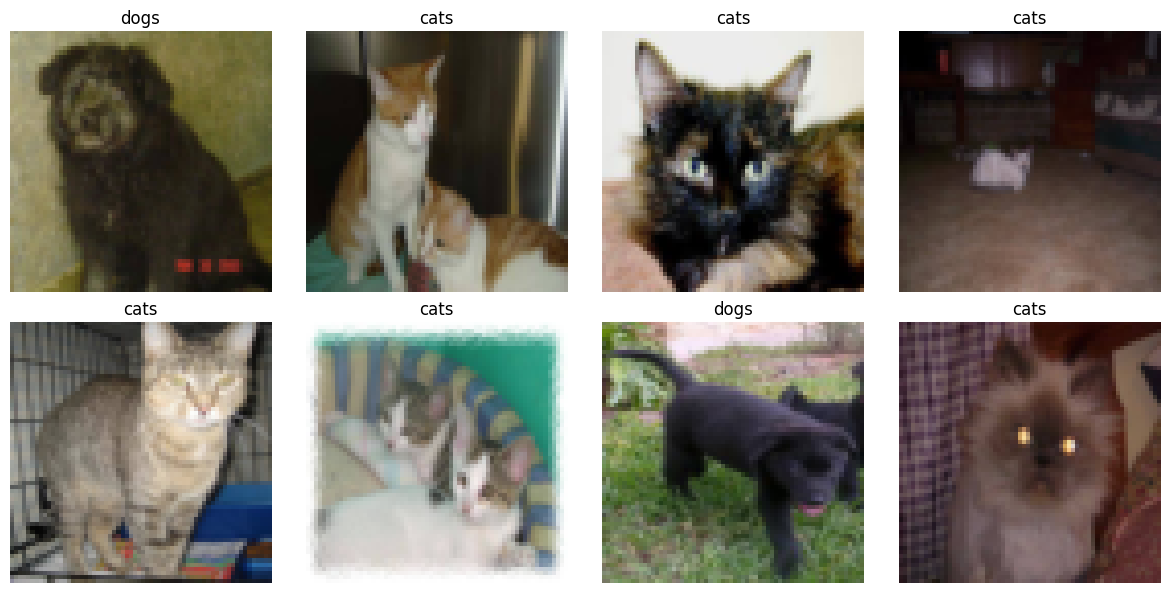

In [5]:
# Lấy một batch để hiển thị
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Denormalize để hiển thị ảnh
def denormalize(tensor):
    tensor = tensor * 0.5 + 0.5  # Chuyển từ [-1, 1] về [0, 1]
    return tensor

# Hiển thị 8 ảnh đầu tiên
plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i+1)
    img = denormalize(images[i])
    img = img.permute(1, 2, 0)  # Chuyển từ (C, H, W) sang (H, W, C)
    plt.imshow(img)
    plt.title(train_dataset.classes[labels[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [6]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        # Flatten layer để chuyển từ (batch, 3, 64, 64) sang (batch, 3*64*64)
        self.flatten = nn.Flatten()
        
        # Các fully connected layers
        # Input: 3 * 64 * 64 = 12,288 features (ảnh RGB 64x64)
        self.fc1 = nn.Linear(3 * 64 * 64, 512)  # Hidden layer 1: 512 neurons
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)  # Dropout để tránh overfitting
        
        self.fc2 = nn.Linear(512, 256)   # Hidden layer 2: 256 neurons
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)
        
        self.fc3 = nn.Linear(256, 128)   # Hidden layer 3: 128 neurons
        self.relu3 = nn.ReLU()
        
        self.fc4 = nn.Linear(128, 2)     # Output layer: 2 classes (cat, dog)
        # Không cần softmax ở đây vì CrossEntropyLoss đã bao gồm softmax
    
    def forward(self, x):
        # Forward pass
        x = self.flatten(x)      # (batch, 3, 64, 64) -> (batch, 12288)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout2(x)
        x = self.fc3(x)
        x = self.relu3(x)
        x = self.fc4(x)
        return x

# Khởi tạo model và chuyển sang device
model = ANN().to(device)
print(model)

# Đếm số parameters
total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters: {total_params:,}')

ANN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=12288, out_features=512, bias=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (relu3): ReLU()
  (fc4): Linear(in_features=128, out_features=2, bias=True)
)

Total parameters: 6,456,450


In [7]:
# Loss function: CrossEntropyLoss cho bài toán phân loại
criterion = nn.CrossEntropyLoss()

# Optimizer: Adam với learning rate 0.001
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [8]:
# Lưu lịch sử training
train_loss_history = []
train_acc_history = []
test_acc_history = []

# Số epochs
num_epochs = 10
total_step = len(train_loader)

for epoch in range(num_epochs):
    model.train()  # Set model về training mode
    running_loss = 0.0
    correct = 0
    total = 0
    
    for i, (images, labels) in enumerate(train_loader):
        # Chuyển data sang device
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass và optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Tính accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        running_loss += loss.item()
        
        # In progress mỗi 20 batches
        if (i+1) % 20 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{total_step}], '
                  f'Loss: {loss.item():.4f}, Acc: {100*correct/total:.2f}%')
    
    # Tính accuracy và loss trung bình của epoch
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    train_loss_history.append(epoch_loss)
    train_acc_history.append(epoch_acc)
    
    # Đánh giá trên test set
    model.eval()  # Set model về evaluation mode
    with torch.no_grad():
        correct = 0
        total = 0
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        test_accuracy = 100 * correct / total
        test_acc_history.append(test_accuracy)
    
    print(f'\n*** Epoch [{epoch+1}/{num_epochs}] Summary ***')
    print(f'Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.2f}%, Test Acc: {test_accuracy:.2f}%')

Epoch [1/10], Step [20/126], Loss: 0.7308, Acc: 53.75%
Epoch [1/10], Step [40/126], Loss: 0.6644, Acc: 54.65%
Epoch [1/10], Step [60/126], Loss: 0.7932, Acc: 55.21%
Epoch [1/10], Step [80/126], Loss: 0.6874, Acc: 56.19%
Epoch [1/10], Step [100/126], Loss: 0.6354, Acc: 56.78%
Epoch [1/10], Step [120/126], Loss: 0.6657, Acc: 57.40%

*** Epoch [1/10] Summary ***
Train Loss: 0.6968, Train Acc: 57.41%, Test Acc: 60.60%
Epoch [2/10], Step [20/126], Loss: 0.6944, Acc: 60.78%
Epoch [2/10], Step [40/126], Loss: 0.6808, Acc: 60.20%
Epoch [2/10], Step [60/126], Loss: 0.6477, Acc: 59.35%
Epoch [2/10], Step [80/126], Loss: 0.6074, Acc: 59.69%
Epoch [2/10], Step [100/126], Loss: 0.6850, Acc: 59.97%
Epoch [2/10], Step [120/126], Loss: 0.6042, Acc: 60.07%

*** Epoch [2/10] Summary ***
Train Loss: 0.6573, Train Acc: 59.98%, Test Acc: 61.39%
Epoch [3/10], Step [20/126], Loss: 0.7165, Acc: 64.14%
Epoch [3/10], Step [40/126], Loss: 0.6671, Acc: 63.63%
Epoch [3/10], Step [60/126], Loss: 0.6838, Acc: 63.12%

In [9]:
# Đánh giá chi tiết trên test set
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    test_accuracy = 100 * correct / total
    print(f'\n*** FINAL TEST ACCURACY: {test_accuracy:.2f}% ***')
    print(f'Correct predictions: {correct}/{total}')


*** FINAL TEST ACCURACY: 65.35% ***
Correct predictions: 1322/2023


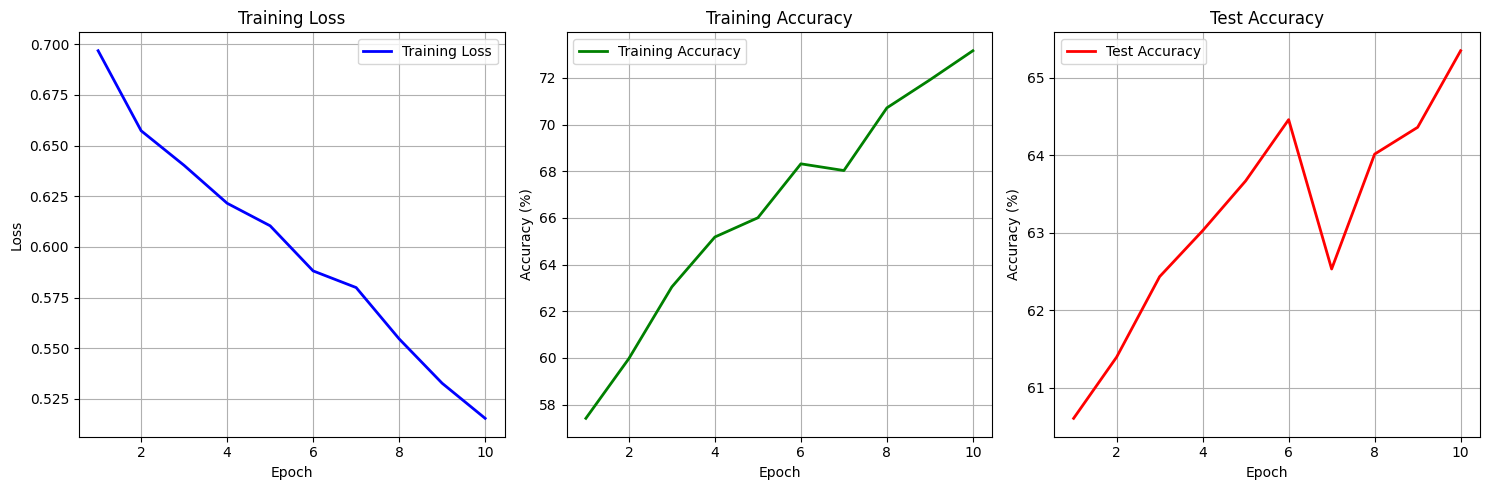

In [10]:
# Vẽ đồ thị Training Loss và Accuracy
epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(15, 5))

# Subplot 1: Training Loss
plt.subplot(1, 3, 1)
plt.plot(epochs_range, train_loss_history, 'b-', label='Training Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(True)

# Subplot 2: Training Accuracy
plt.subplot(1, 3, 2)
plt.plot(epochs_range, train_acc_history, 'g-', label='Training Accuracy', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training Accuracy')
plt.legend()
plt.grid(True)

# Subplot 3: Test Accuracy
plt.subplot(1, 3, 3)
plt.plot(epochs_range, test_acc_history, 'r-', label='Test Accuracy', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Test Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()